
**Dataset:** UCI Heart Disease Dataset  
**Goal:** To predict the likelihood of heart disease using machine learning.

---
## 1. importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
print('Libraries imported successfully.')

Libraries imported successfully.


---
## 2. To load the dataset


In [2]:

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(url, names=columns, na_values='?')

# 0 = No Disease, 1 = Disease
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


---
## 3. Exploratory Data Analysis (EDA)

In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [4]:
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


In [5]:

print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


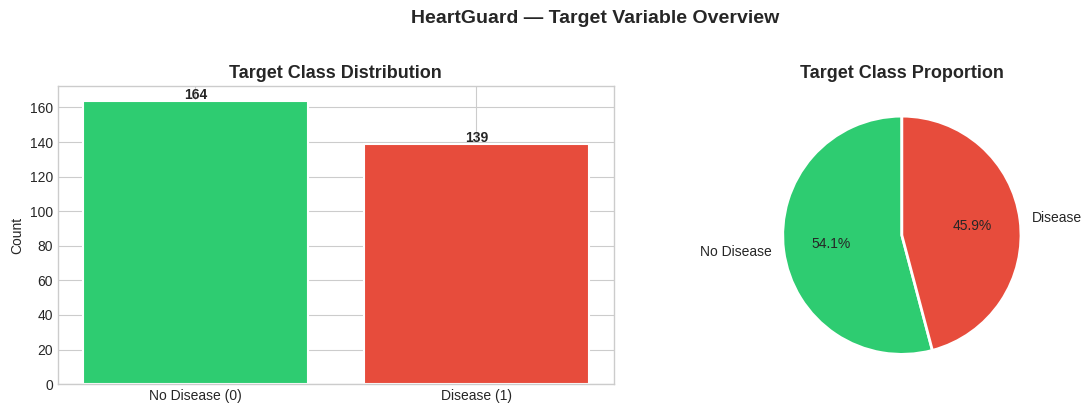

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['target'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], target_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['No Disease', 'Disease'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Target Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('HeartGuard — Target Variable Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

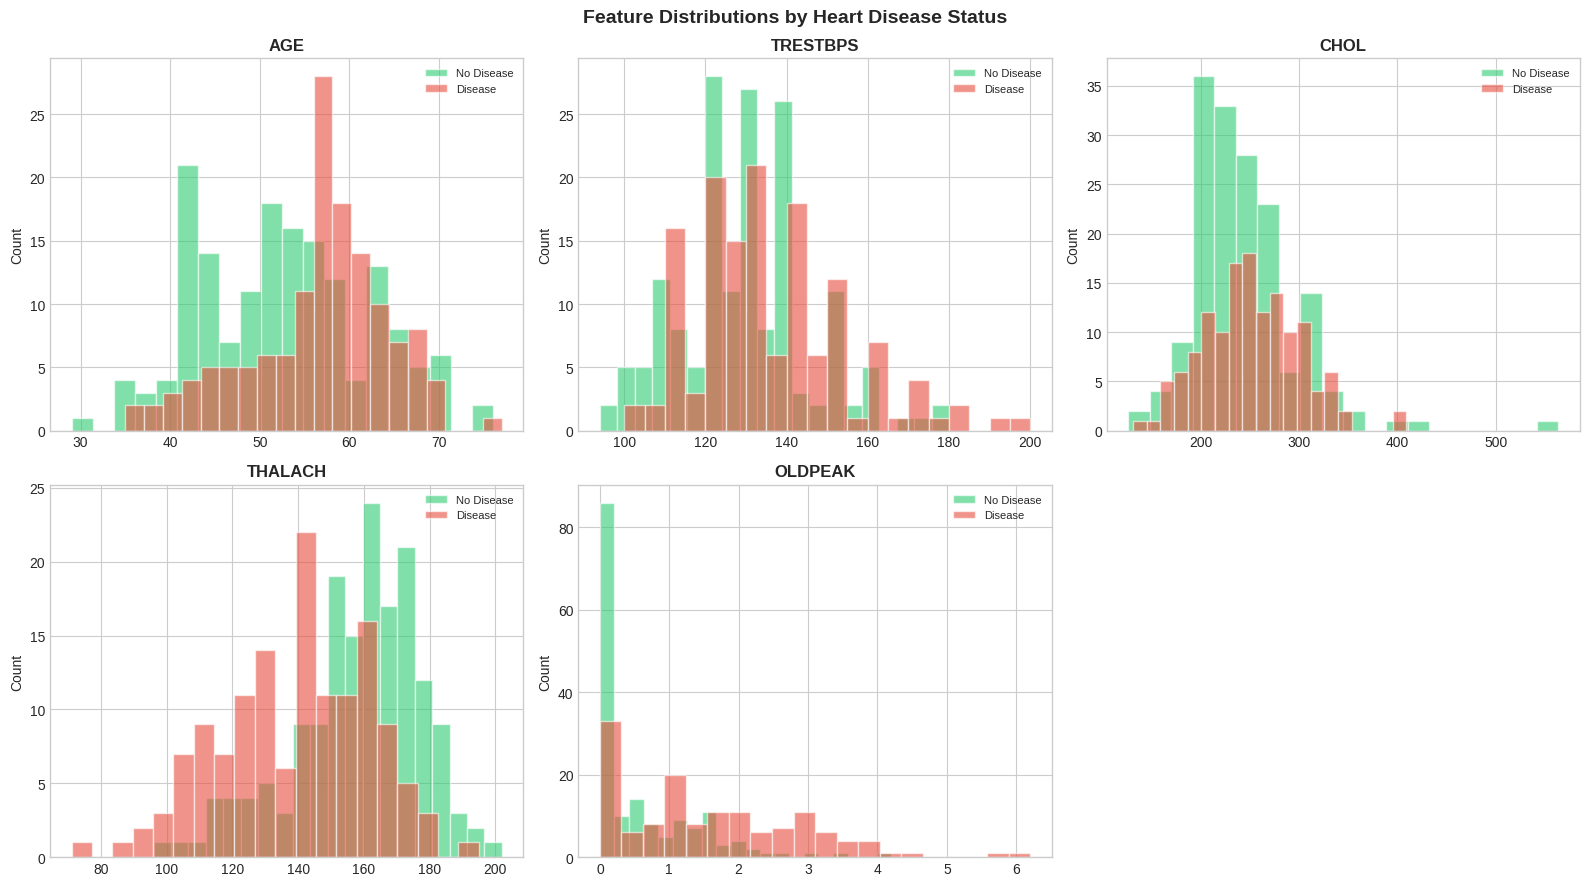

In [7]:
# Feature distributions by target
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], ['No Disease', 'Disease']):
        axes[i].hist(df[df['target'] == label][col].dropna(),
                     alpha=0.6, color=color, label=name, bins=20, edgecolor='white')
    axes[i].set_title(col.upper(), fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Count')

axes[-1].axis('off')
fig.suptitle('Feature Distributions by Heart Disease Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

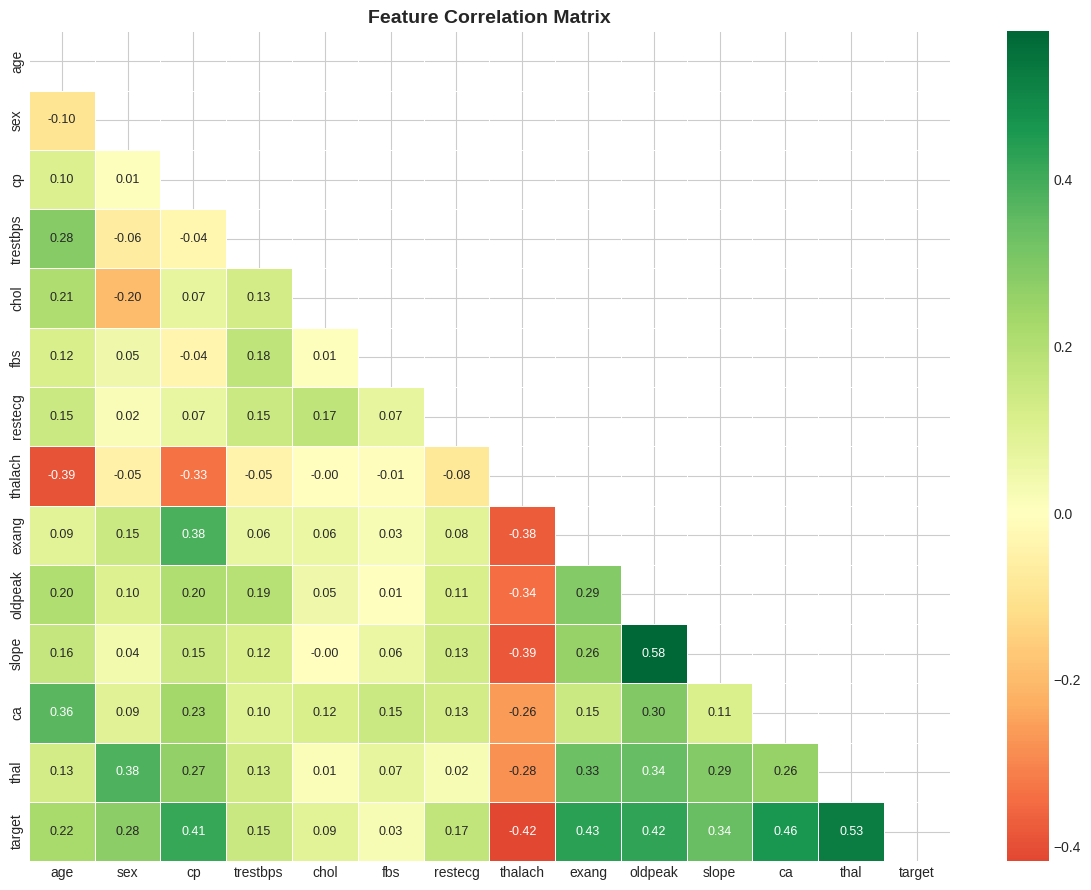

In [8]:
#  heatmap
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

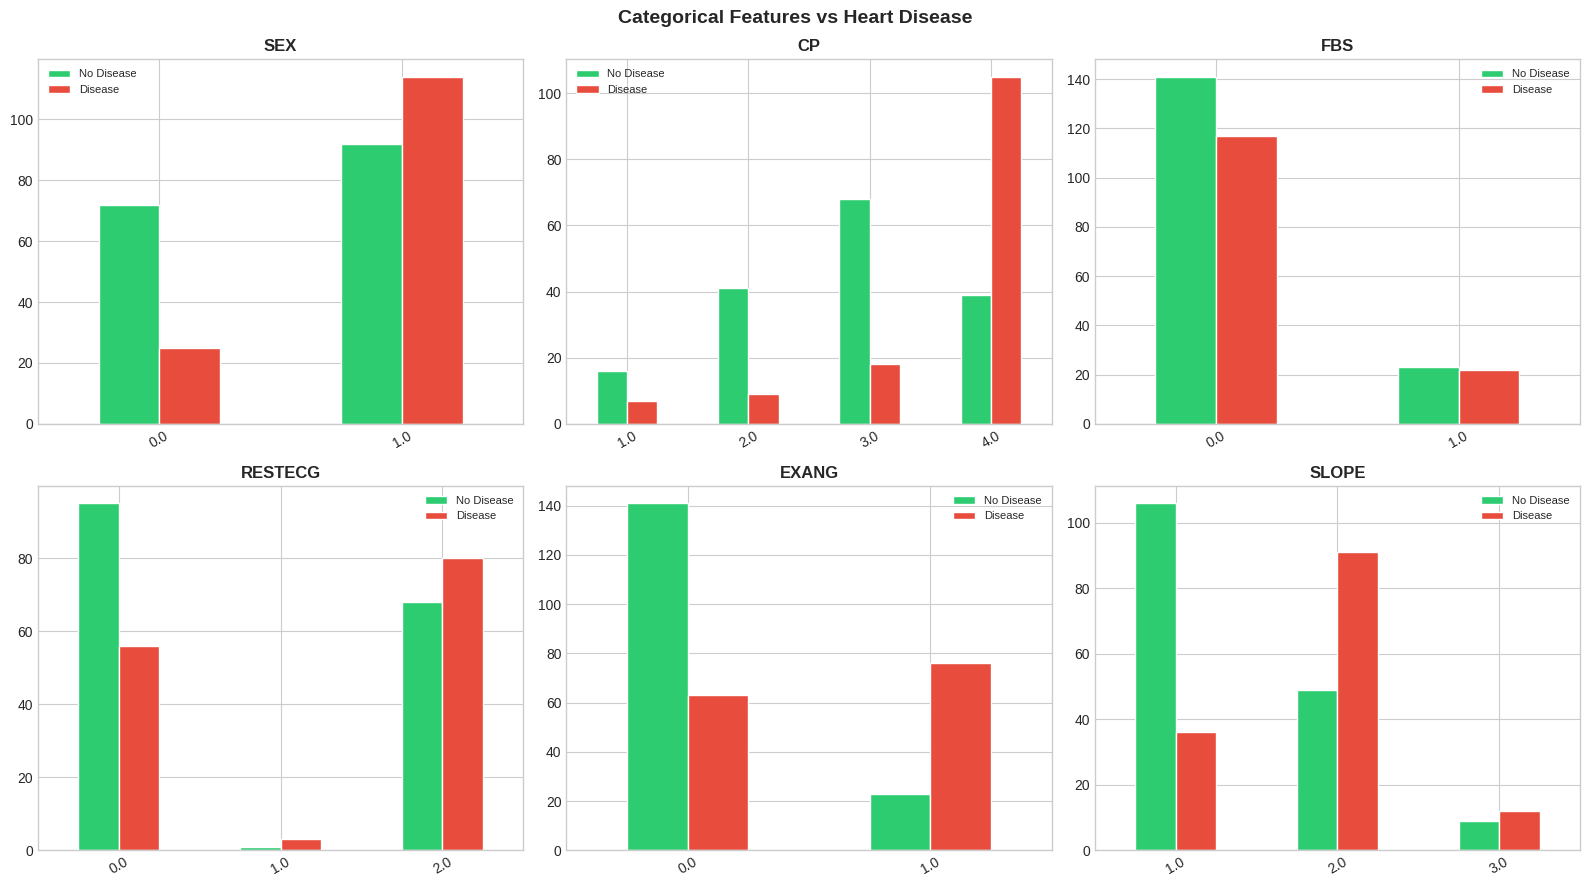

In [9]:
# feature analysis according to category
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
cat_labels = {
    'sex': {0: 'Female', 1: 'Male'},
    'cp': {0: 'Typical', 1: 'Atypical', 2: 'Non-anginal', 3: 'Asymptomatic'},
    'fbs': {0: 'FBS ≤ 120', 1: 'FBS > 120'},
    'restecg': {0: 'Normal', 1: 'ST-T Abnormal', 2: 'LV Hypertrophy'},
    'exang': {0: 'No', 1: 'Yes'},
    'slope': {0: 'Upsloping', 1: 'Flat', 2: 'Downsloping'}
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    grp = df.groupby([col, 'target']).size().unstack(fill_value=0)
    grp.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
             edgecolor='white', linewidth=1)
    axes[i].set_title(col.upper(), fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(['No Disease', 'Disease'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

fig.suptitle('Categorical Features vs Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Data Preprocessing

In [10]:
# filling missing values with column median
df.fillna(df.median(numeric_only=True), inplace=True)
print('Missing values after imputation:', df.isnull().sum().sum())

Missing values after imputation: 0


In [11]:
# Label Encoding for categorical columns
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
le = LabelEncoder()

df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print('Label Encoding applied to:', categorical_cols)
df_encoded.head()

Label Encoding applied to: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1,0,145.0,233.0,1,2,150.0,0,2.3,2,0,1,0
1,67.0,1,3,160.0,286.0,0,2,108.0,1,1.5,1,3,0,1
2,67.0,1,3,120.0,229.0,0,2,129.0,1,2.6,1,2,2,1
3,37.0,1,2,130.0,250.0,0,0,187.0,0,3.5,2,0,0,0
4,41.0,0,1,130.0,204.0,0,2,172.0,0,1.4,0,0,0,0


In [12]:
# Features & target split
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train_sc, X_test_sc, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 242 | Test size: 61


---
## 5. Model Training & K-Fold Cross Validation

In [13]:
kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Random Forest':        (RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE), X, y),
    'Logistic Regression':  (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_scaled, y),
    'SVM':                  (SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE), X_scaled, y)
}

kfold_results = {}

for name, (model, X_in, y_in) in models.items():
    scores = cross_val_score(model, X_in, y_in, cv=kf, scoring='accuracy')
    kfold_results[name] = scores
    print(f'{name:22s} | Mean Acc: {scores.mean():.4f} | Std: {scores.std():.4f}')

Random Forest          | Mean Acc: 0.8284 | Std: 0.0683
Logistic Regression    | Mean Acc: 0.8383 | Std: 0.0541
SVM                    | Mean Acc: 0.8380 | Std: 0.0507


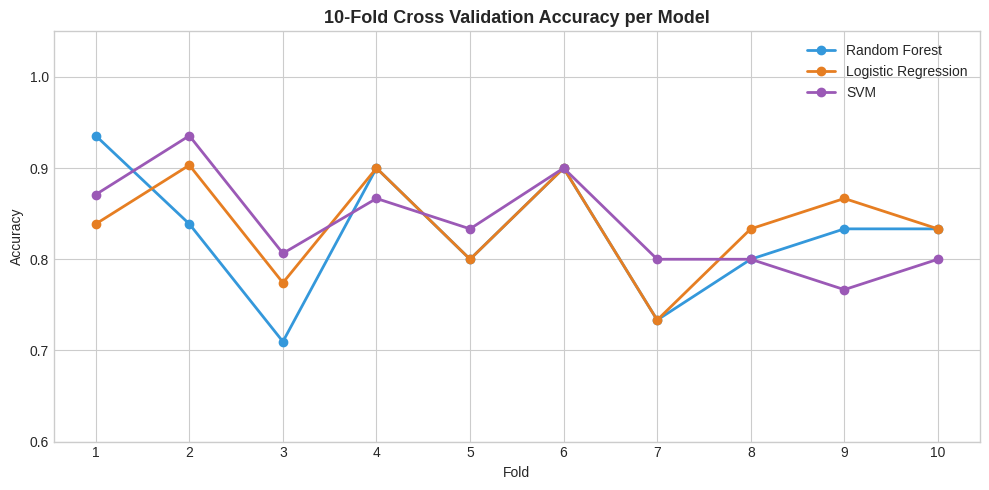

In [14]:
# K-Fold results visualisation
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#3498db', '#e67e22', '#9b59b6']
for i, (name, scores) in enumerate(kfold_results.items()):
    ax.plot(range(1, 11), scores, marker='o', label=name, color=colors[i], linewidth=2)

ax.set_title('10-Fold Cross Validation Accuracy per Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_xticks(range(1, 11))
ax.legend()
ax.set_ylim(0.6, 1.05)
plt.tight_layout()
plt.savefig('kfold_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Model Evaluation on Test Set

In [16]:
# Fit each model on training data and evaluate on test set
fitted_models = {}
test_results = {}

rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
fitted_models['Random Forest'] = (rf, X_test)

lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_sc, y_train)
fitted_models['Logistic Regression'] = (lr, X_test_sc)

svm = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
svm.fit(X_train_sc, y_train)
fitted_models['SVM'] = (svm, X_test_sc)

print('All models trained on training set.\n')

for name, (model, X_t) in fitted_models.items():
    y_pred = model.predict(X_t)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_t)[:, 1])
    test_results[name] = {'y_pred': y_pred, 'y_proba': model.predict_proba(X_t)[:, 1],
                          'accuracy': acc, 'roc_auc': auc}
    print(f'{name:22s} | Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f}')

All models trained on training set.

Random Forest          | Accuracy: 0.8852 | ROC-AUC: 0.9540
Logistic Regression    | Accuracy: 0.8689 | ROC-AUC: 0.9535
SVM                    | Accuracy: 0.8525 | ROC-AUC: 0.9475


In [17]:
# Classification reports
for name, res in test_results.items():
    print(f'\n--- {name} ---')
    print(classification_report(y_test, res['y_pred'], target_names=['No Disease', 'Disease']))


--- Random Forest ---
              precision    recall  f1-score   support

  No Disease       0.93      0.85      0.89        33
     Disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61


--- Logistic Regression ---
              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


--- SVM ---
              precision    recall  f1-score   support

  No Disease       0.90      0.82      0.86        33
     Disease       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted 

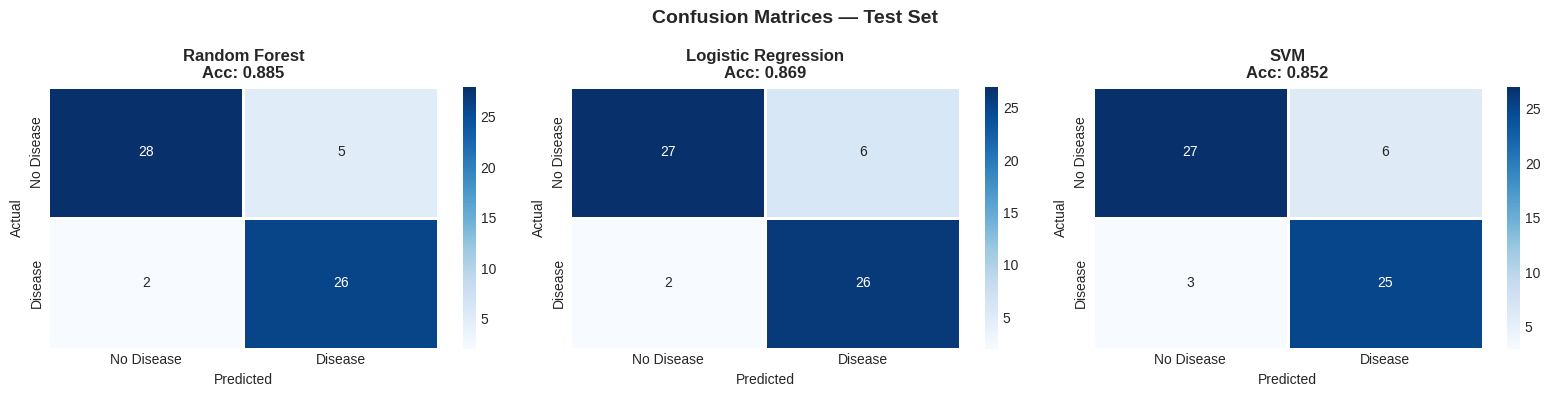

In [18]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=1, linecolor='white')
    ax.set_title(f'{name}\nAcc: {res["accuracy"]:.3f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

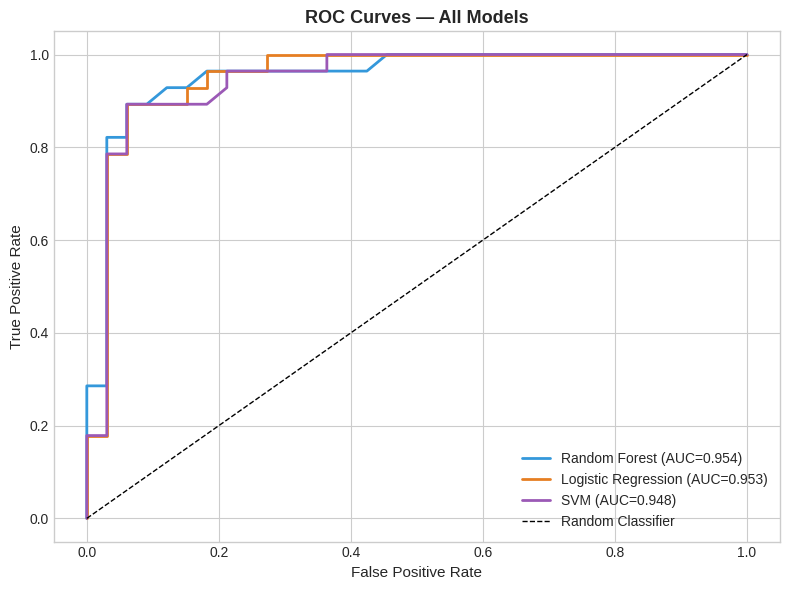

In [19]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#3498db', '#e67e22', '#9b59b6']
for (name, res), color in zip(test_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})",
            color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Feature Importance (Random Forest)

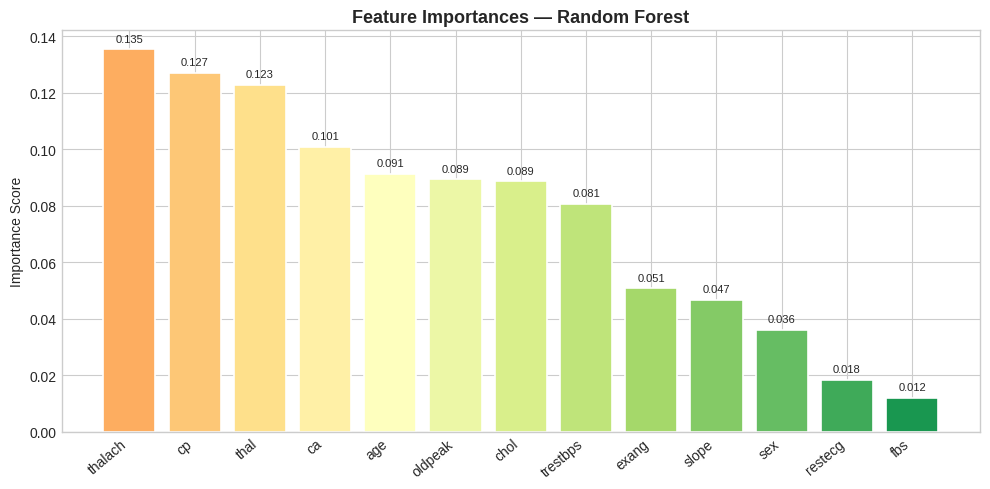

In [20]:
feature_names = X.columns.tolist()
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(feature_names)),
              importances[indices],
              color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feature_names))),
              edgecolor='white', linewidth=1.2)

ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels([feature_names[i] for i in indices], rotation=40, ha='right')
ax.set_title('Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance Score')

for bar, imp in zip(bars, importances[indices]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{imp:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Model Comparison Summary

In [21]:
comparison = pd.DataFrame({
    'Model': list(test_results.keys()),
    'Test Accuracy': [res['accuracy'] for res in test_results.values()],
    'ROC-AUC': [res['roc_auc'] for res in test_results.values()],
    'CV Mean Accuracy': [kfold_results[m].mean() for m in test_results.keys()],
    'CV Std': [kfold_results[m].std() for m in test_results.keys()]
}).set_index('Model').round(4)

print('\n===== MODEL COMPARISON SUMMARY =====')
print(comparison.to_string())


===== MODEL COMPARISON SUMMARY =====
                     Test Accuracy  ROC-AUC  CV Mean Accuracy  CV Std
Model                                                                
Random Forest               0.8852   0.9540            0.8284  0.0683
Logistic Regression         0.8689   0.9535            0.8383  0.0541
SVM                         0.8525   0.9475            0.8380  0.0507


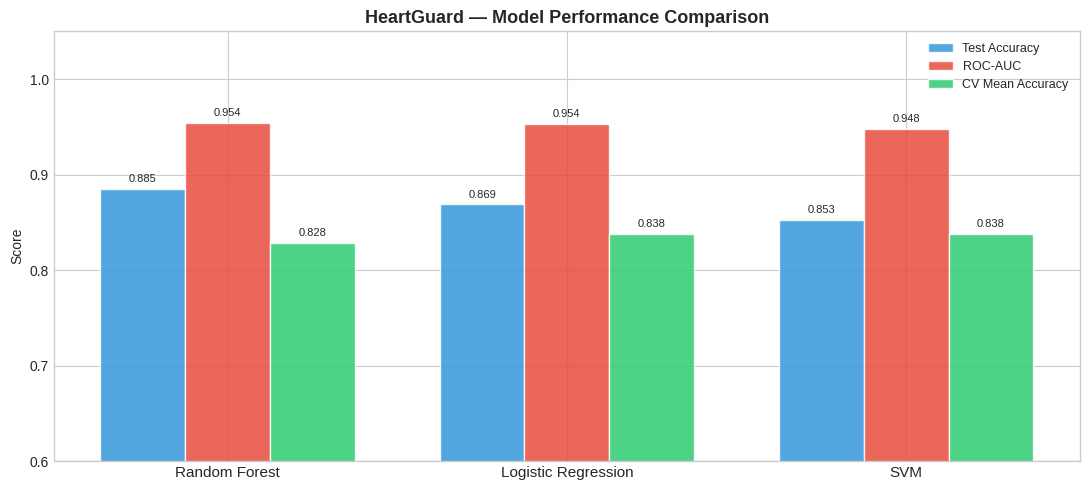

In [22]:
# Bar chart for comparison
metrics = ['Test Accuracy', 'ROC-AUC', 'CV Mean Accuracy']
x = np.arange(len(comparison.index))
width = 0.25
colors_bar = ['#3498db', '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    bars = ax.bar(x + i * width, comparison[metric], width,
                  label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(comparison.index, fontsize=11)
ax.set_ylim(0.6, 1.05)
ax.set_ylabel('Score')
ax.set_title('HeartGuard — Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Patient Prediction Demo

In [23]:
# Demo: predict for a single patient using the best model (Random Forest)


sample_patient = pd.DataFrame([{
    'age': 54, 'sex': 1, 'cp': 2, 'trestbps': 130, 'chol': 250,
    'fbs': 0, 'restecg': 1, 'thalach': 147, 'exang': 0,
    'oldpeak': 1.4, 'slope': 1, 'ca': 1, 'thal': 2
}])

# Apply same label encoding
for col in categorical_cols:
    sample_patient[col] = le.fit_transform(sample_patient[col].astype(str))

prediction = rf.predict(sample_patient)[0]
probability = rf.predict_proba(sample_patient)[0][1]

print('====== HeartGuard Patient Report ======')
print(f'Diagnosis      : {"⚠️  Heart Disease Detected" if prediction == 1 else "✅  No Heart Disease"}')
print(f'Risk Probability: {probability * 100:.1f}%')
print('=======================================')

====== HeartGuard Patient Report ======
Diagnosis      : ✅  No Heart Disease
Risk Probability: 11.0%


In [24]:
# saving model to use it locally in streamlit
import pandas as pd
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(url, names=columns, na_values='?')
df.dropna(inplace=True)

# Convert target
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Encode categorical
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# Split
X = df.drop('target', axis=1)
y = df['target']

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save encoders
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("✅ Model and encoders saved!")

✅ Model and encoders saved!
